# Libraries

In [591]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve



In [592]:
import os
path = R'D:\Repository\credit_scoring_model\dataset'
os.chdir(path)

# Loading the dataset

In [593]:
df = pd.read_csv('bank.csv',  sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [594]:
df.shape

(4521, 17)

In [595]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [596]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [597]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [598]:
df.duplicated().sum()

np.int64(0)

In [599]:
df_clean = df.copy()

In [600]:
df_clean.columns = df_clean.columns.str.capitalize()

for i in df_clean.select_dtypes(exclude=['number']).columns:
    df_clean[i] = df_clean[i].str.capitalize()
    
df_clean.head()

,Age,Job,Marital,Education,Default,Balance,Housing,Loan,Contact,Day,Month,Duration,Campaign,Pdays,Previous,Poutcome,Y
0,30,Unemployed,Married,Primary,No,1787,No,No,Cellular,19,Oct,79,1,-1,0,Unknown,No
1,33,Services,Married,Secondary,No,4789,Yes,Yes,Cellular,11,May,220,1,339,4,Failure,No
2,35,Management,Single,Tertiary,No,1350,Yes,No,Cellular,16,Apr,185,1,330,1,Failure,No
3,30,Management,Married,Tertiary,No,1476,Yes,Yes,Unknown,3,Jun,199,4,-1,0,Unknown,No
4,59,Blue-collar,Married,Secondary,No,0,Yes,No,Unknown,5,May,226,1,-1,0,Unknown,No


# Exploratory Data Analysis 

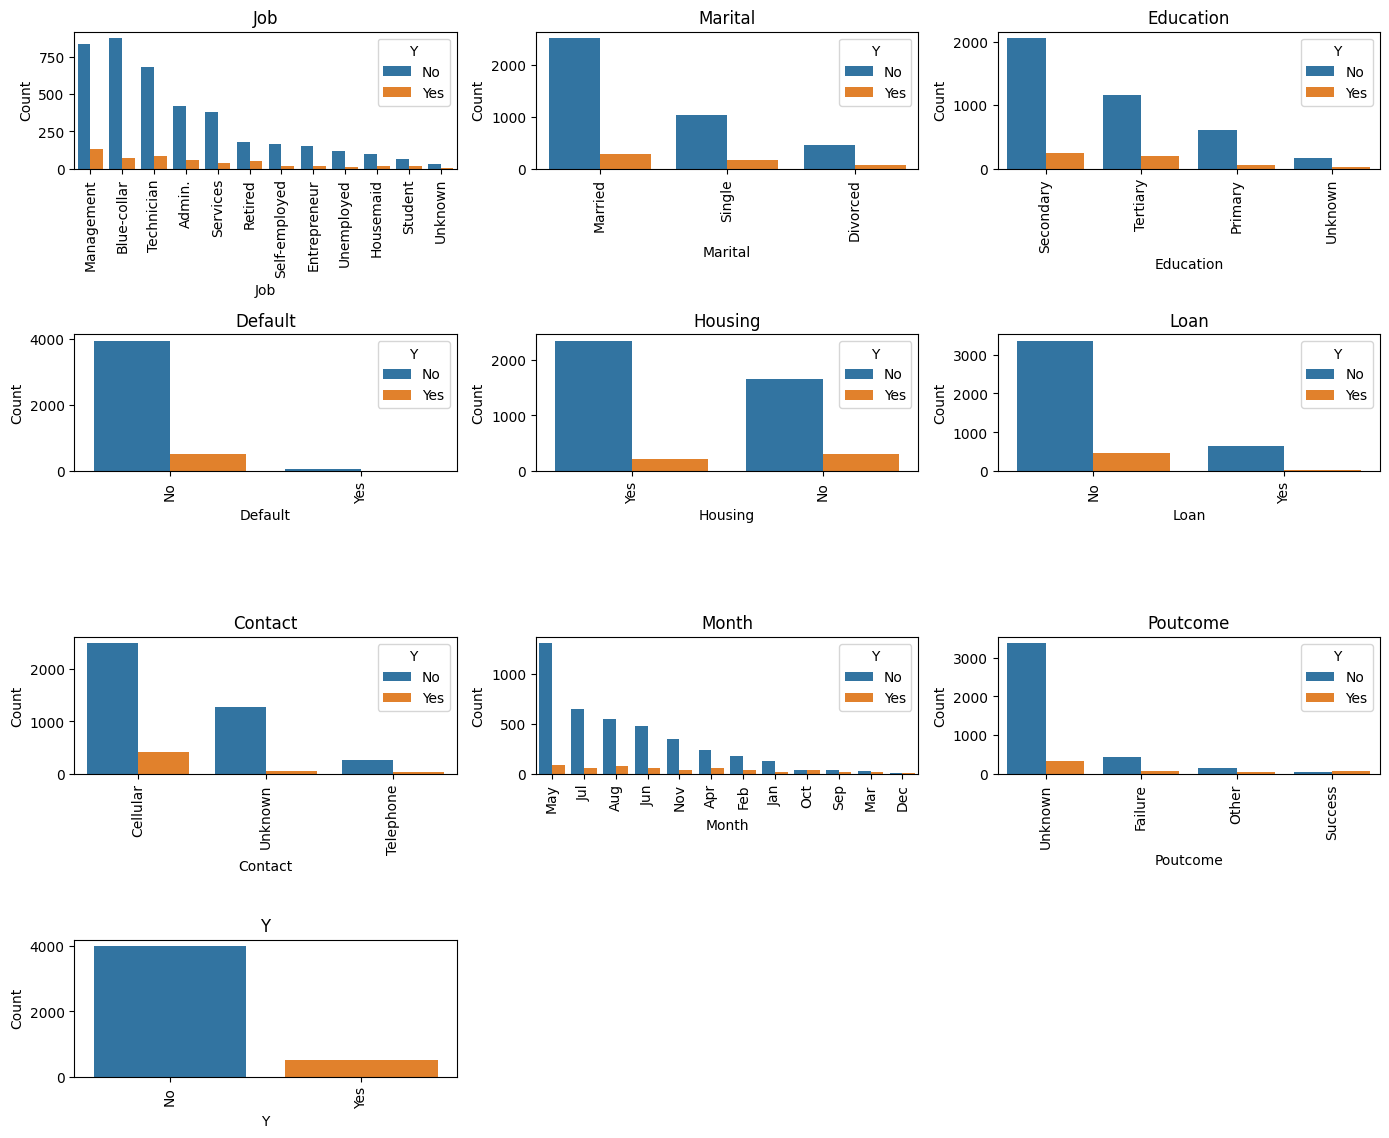

In [601]:
categorical_cols = df_clean.select_dtypes(exclude=['number']).columns
plt.figure(figsize=(14, 14))
for i, col in enumerate(categorical_cols):
    plt.subplot(5, 3, i+1)
    sns.countplot(x=df_clean[col], hue=df_clean['Y'], order = df_clean[col].value_counts().index)    
    plt.title(col)    
    plt.xticks(rotation=90)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


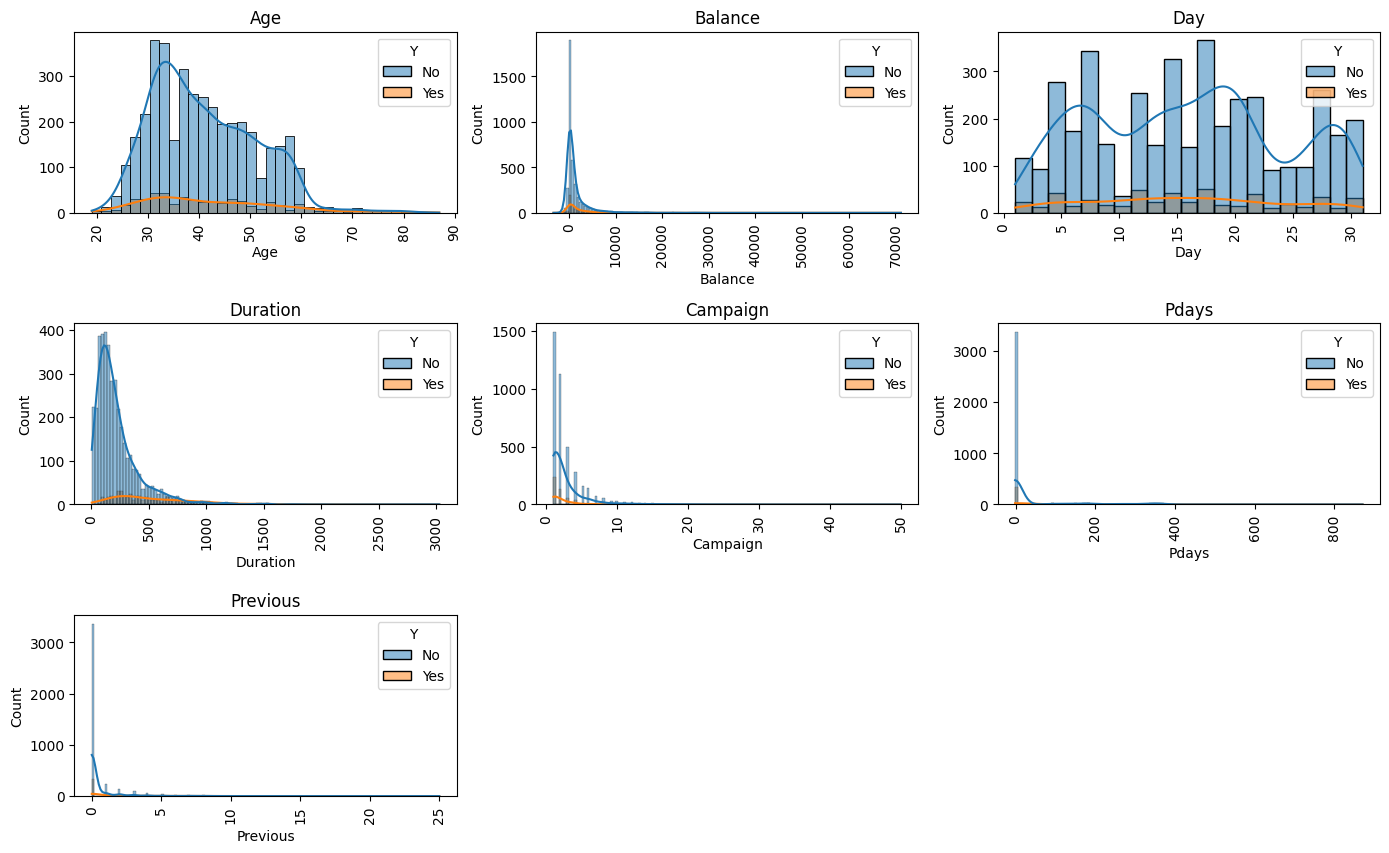

In [602]:
numerical_cols = df_clean.select_dtypes(include=['number']).columns
plt.figure(figsize=(14, 14))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 3, i+1)
    sns.histplot(x=df_clean[col], hue=df_clean['Y'], kde=True)    
    plt.title(col)    
    plt.xticks(rotation=90)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


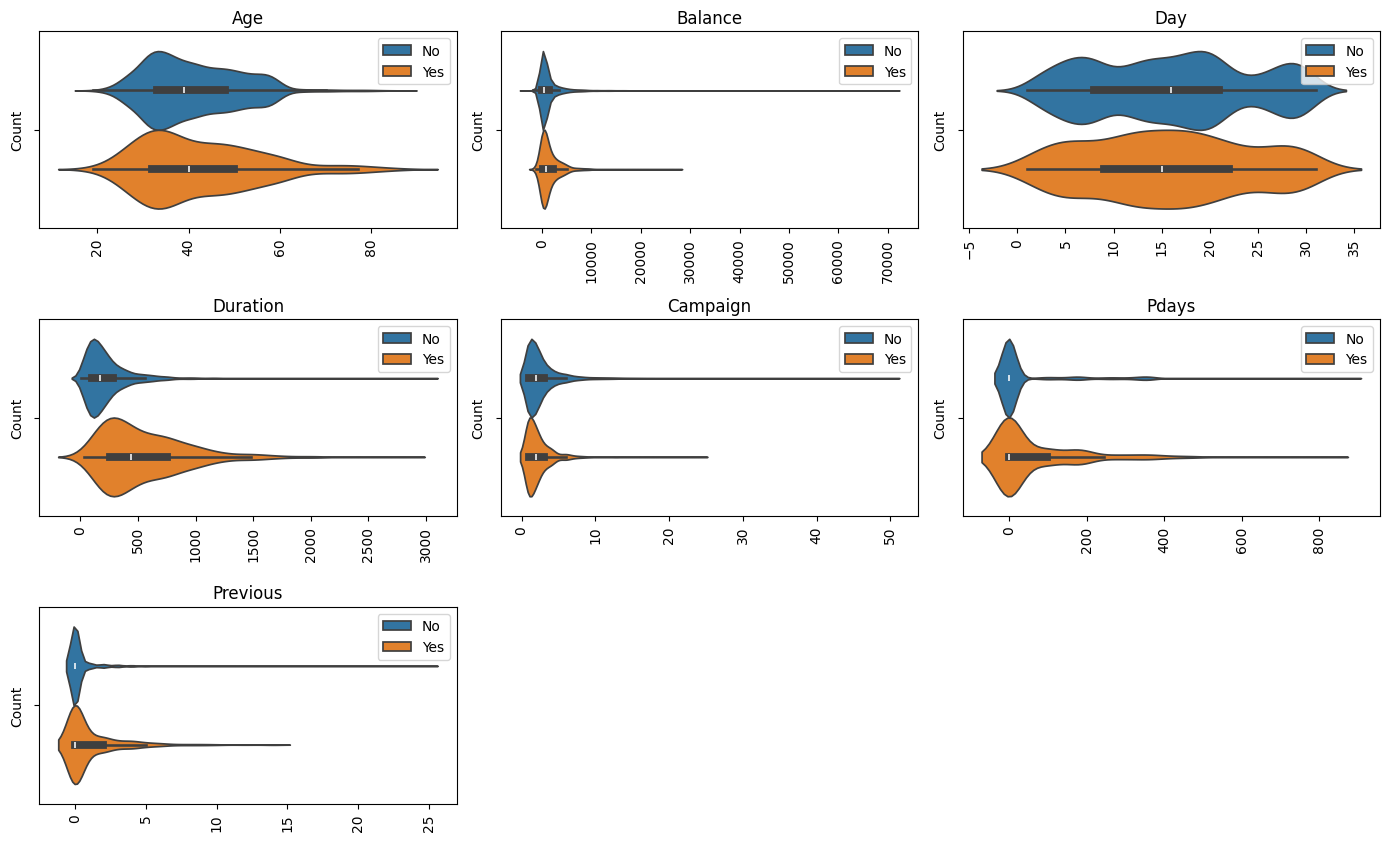

In [603]:
plt.figure(figsize=(14, 14))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 3, i+1)
    sns.violinplot(x=df_clean[col], hue=df_clean['Y'])
    plt.title(col)    
    plt.xticks(rotation=90)
    plt.ylabel('Count')
    plt.xlabel('')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


# Modeling

In [604]:
X = df_clean.drop(columns=['Y'])
y = df_clean['Y'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [605]:
numerical_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(exclude=['number']).columns

In [606]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_cols),
    ('categorical', categorical_transformer, categorical_cols),
])

model = Pipeline([
    ('preprocessing', preprocessing),
    ('smote', SMOTE()),
    ('classifier', LogisticRegression())
])

In [607]:
param_grid = {
    'classifier__max_iter': [1000],
    'classifier__C': [0.1, 1, 10],
    'classifier__random_state': [42],
    'smote__k_neighbors': [5, 10, 15],
    'smote__random_state': [42],
}

search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__max_iter': [1000], 'classifier__random_state': [42], 'smote__k_neighbors': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [608]:
y_pred = search.predict_proba(X_test)[:, 1]
y_pred = (y_pred > 0.75).astype(int)
print("Classification Report")
print(classification_report(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print(f'ROC_AUC :{roc_auc_score(y_test, y_pred)}')    
print(f'Best params: {search.best_params_}')


Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       801
           1       0.45      0.56      0.50       104

    accuracy                           0.87       905
   macro avg       0.69      0.73      0.71       905
weighted avg       0.88      0.87      0.88       905

Confusion Matrix
[[729  72]
 [ 46  58]]
ROC_AUC :0.7339023336214348
Best params: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__random_state': 42, 'smote__k_neighbors': 10, 'smote__random_state': 42}


In [609]:
model = Pipeline([
    ('preprocessing', preprocessing),
    ('smote', SMOTE()),
    ('classifier', DecisionTreeClassifier())
])

In [610]:
param_grid = {
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__random_state': [42],
    'smote__k_neighbors': [5, 10, 15],
    'smote__random_state': [42]
}

search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__random_state': [42], 'smote__k_neighbors': [5, 10, ...], 'smote__random_state': [42]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [611]:
y_pred = search.predict_proba(X_test)[:, 1]
y_pred = (y_pred > 0.8).astype(int)
print("Classification Report")
print(classification_report(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print(f'ROC_AUC :{roc_auc_score(y_test, y_pred)}')    
print(f'Best params: {search.best_params_}')


Classification Report
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       801
           1       0.44      0.59      0.50       104

    accuracy                           0.87       905
   macro avg       0.69      0.75      0.71       905
weighted avg       0.89      0.87      0.88       905

Confusion Matrix
[[724  77]
 [ 43  61]]
ROC_AUC :0.7452043119177951
Best params: {'classifier__max_depth': 10, 'classifier__random_state': 42, 'smote__k_neighbors': 10, 'smote__random_state': 42}


In [612]:
model = Pipeline([
    ('preprocessing', preprocessing),
    ('smote', SMOTE()),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [613]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__random_state': [42],
    'smote__k_neighbors': [5, 10, 15],
    'smote__random_state': [42]
}

search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__n_estimators': [100, 200, ...], 'classifier__random_state': [42], 'smote__k_neighbors': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [614]:
# 1. Get raw probabilities
y_probs = search.predict_proba(X_test)[:, 1]

# 2. Set your threshold (0.5)
y_class = (y_probs > 0.25).astype(int)

print("Classification Report")
print(classification_report(y_test, y_class))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_class))

print(f'True ROC_AUC: {roc_auc_score(y_test, y_probs)}')

print(f'Threshold-based AUC: {roc_auc_score(y_test, y_class)}')

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       801
           1       0.42      0.83      0.55       104

    accuracy                           0.85       905
   macro avg       0.69      0.84      0.73       905
weighted avg       0.91      0.85      0.87       905

Confusion Matrix
[[680 121]
 [ 18  86]]
True ROC_AUC: 0.8895251128397197
Threshold-based AUC: 0.8379309516949965


In [620]:
labeled_data = X_test.copy()
labeled_data['subscription_probability'] = search.predict_proba(X_test)[:, 1]
labeled_data['predicted_label'] = search.predict(X_test)

labeled_data['priority'] = pd.cut(
    labeled_data['subscription_probability'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Ignore', 'Low', 'Medium', 'High']
)

print(labeled_data[['subscription_probability', 'predicted_label', 'priority']].sample(10))

      subscription_probability  predicted_label priority
1080                      0.00                0      NaN
4250                      0.02                0   Ignore
2490                      0.04                0   Ignore
1933                      0.02                0   Ignore
2898                      0.03                0   Ignore
3437                      0.06                0   Ignore
711                       0.04                0   Ignore
4222                      0.01                0   Ignore
4286                      0.20                0   Ignore
2767                      0.15                0   Ignore
